# HW06: Attention

Remember that these homework work as a completion grade. **You can <span style="color:red">not</span> skip one section this homework.**

### Data sampling with a sliding window

In this intro code I will ask you to revise what we saw on the lab to test your understanding of the features.

In [1]:
#Import the AG news dataset (same as hw01)
#Download them from here 
# !wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 
df["text"] = df["title"] + " " + df["lead"]
df = df.sample(n=10000) # # only use 10K datapoints
df.head()

,label,title,lead,text
46164,sport,Pound suggests Hamilton skirted justice,WADA chief suggests cyclist got away with dopi...,Pound suggests Hamilton skirted justice WADA c...
102586,sport,Ten things we learned this week in the NBA,"1. Item: At 71, Hubie Brown suddenly retired a...",Ten things we learned this week in the NBA 1. ...
90008,sport,No. 3 Auburn Dominates Georgia 24-6,Auburn #39;s Devin Aromashodu can #39;t hang o...,No. 3 Auburn Dominates Georgia 24-6 Auburn #39...
115253,sci/tech,"Samsung, Sony to share patents",TOKYO (CBS.MW) - Samsung Electronics Co. Ltd. ...,"Samsung, Sony to share patents TOKYO (CBS.MW) ..."
32449,business,Bush to Visit Hurricane-Stricken States,"PENSACOLA, Florida _ In the wake of Hurricane ...",Bush to Visit Hurricane-Stricken States PENSAC...


By now you should have a clear understanding of how this data is conformed. 

In [2]:
#TODO clean up the text as best as you can. Build a function to do this and generate a new variable called 'text_clean'
# - decoded HTML entities (e.g. #39; → apostrophe)
# - lowercased
# - removed punctuation and special characters
# - stripped extra whitespace

import re
import html

def clean_text(text):
    text = html.unescape(text)                   # decode HTML entities (&amp; #39; etc.)
    text = re.sub(r'#\d+;', '', text)            # remove any remaining numeric HTML refs like #39;
    text = text.lower()                          # lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)     # keep only letters, digits, spaces
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    return text

df['text_clean'] = df['text'].apply(clean_text)
df[['text', 'text_clean']].head()

,text,text_clean
46164,Pound suggests Hamilton skirted justice WADA c...,pound suggests hamilton skirted justice wada c...
102586,Ten things we learned this week in the NBA 1. ...,ten things we learned this week in the nba 1 i...
90008,No. 3 Auburn Dominates Georgia 24-6 Auburn #39...,no 3 auburn dominates georgia 246 auburn s dev...
115253,"Samsung, Sony to share patents TOKYO (CBS.MW) ...",samsung sony to share patents tokyo cbsmw sams...
32449,Bush to Visit Hurricane-Stricken States PENSAC...,bush to visit hurricanestricken states pensaco...


In [1]:
#TODO using byte-pair encoding, tokenize the first article of the dataset. select 10 tokens that make a coherent sentence
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")


#TODO For this 10 tokens, use the sliding window DataLoader seen in the lab to generate the input and target tensors:

from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt) # Tokenizes the entire text

        for i in range(0, len(token_ids) - max_length, stride):  # Uses a sliding window to chunk the book into overlapping sequences of max_length
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self): # Returns the total number of rows in the dataset
        return len(self.input_ids)

    def __getitem__(self, idx):  # Returns a single row from the dataset
        return self.input_ids[idx], self.target_ids[idx]

# Now A data loader to generate batches with input-with pairs
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2") # Initializes the tokenizer
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride) # Creates dataset
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last, # drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training. (See Rashkca A6)
        num_workers=num_workers  # The number of CPU processes to use for preprocessing
    )

    return dataloader

In [ ]:
import torch

tokenizer_gpt2 = tiktoken.get_encoding("gpt2")

# 10-token sample from the first article (same as used in the embeddings section)
sample_tokens = tokenizer_gpt2.encode(df['text_clean'].iloc[0])[:10]
sample_text   = tokenizer_gpt2.decode(sample_tokens)
print(f"10-token sample: {sample_text!r}\n")

# 3 combinations of (max_length, stride)
# Window mechanics: input = tokens[i : i+max_length]
#                   target = tokens[i+1 : i+max_length+1]  (shifted right by 1)
configs = [
    (4, 1, "stride=1  → maximum overlap; every 1-token shift produces a new window"),
    (4, 2, "stride=2  → half overlap; adjacent windows share 2 tokens"),
    (3, 3, "stride=3  → no overlap; stride equals window length, sequence tiled cleanly"),
]

for max_length, stride, explanation in configs:
    dataset = GPTDatasetV1(sample_text, tokenizer_gpt2, max_length, stride)
    print("─" * 65)
    print(f"max_length={max_length}, stride={stride}  →  {len(dataset)} window(s)")
    print(f"  {explanation}\n")
    for i in range(len(dataset)):
        inp_ids, tgt_ids = dataset[i]
        inp_words = tokenizer_gpt2.decode(inp_ids.tolist())
        tgt_words = tokenizer_gpt2.decode(tgt_ids.tolist())
        print(f"  Window {i+1}:")
        print(f"    input  → {inp_words!r}")
        print(f"    target → {tgt_words!r}")
        print(f"    (target is input shifted right by 1: each position predicts the next token)")
    print()

# ── Additional combos on longer text to show richer sliding-window patterns ────
# Using 50 tokens gives enough room to see how window count scales with stride.
long_tokens = tokenizer_gpt2.encode(df['text_clean'].iloc[0])[:50]
long_text   = tokenizer_gpt2.decode(long_tokens)
print(f"50-token sample: {long_text!r}\n")

long_configs = [
    (8, 4,  "stride=half window → standard pretraining overlap; each token appears in ~2 windows"),
    (16, 8, "stride=half window, larger context → model sees longer dependencies per sample"),
]

for max_length, stride, explanation in long_configs:
    dataset = GPTDatasetV1(long_text, tokenizer_gpt2, max_length, stride)
    print("─" * 65)
    print(f"max_length={max_length}, stride={stride}  →  {len(dataset)} window(s)")
    print(f"  {explanation}\n")
    for i in range(len(dataset)):
        inp_ids, tgt_ids = dataset[i]
        print(f"  Window {i+1}:")
        print(f"    input  → {tokenizer_gpt2.decode(inp_ids.tolist())!r}")
        print(f"    target → {tokenizer_gpt2.decode(tgt_ids.tolist())!r}")
    print()




### Word and positional embeddings

In [4]:
#TODO Using the input tokens, create a token embedding layer and look up the embeddings
import torch
import torch.nn as nn

# re-tokenize the first article and take the first 10 tokens (from the earlier TODO)
tokenizer_gpt2 = tiktoken.get_encoding("gpt2")
sample_ids = torch.tensor(tokenizer_gpt2.encode(df['text_clean'].iloc[0])[:10])  # shape: (10,)
print("input token ids:", sample_ids)
print("decoded:", tokenizer_gpt2.decode(sample_ids.tolist()))

vocab_size = tokenizer_gpt2.n_vocab   # 50,257 for GPT-2
embed_dim  = 256

token_embedding_layer  = nn.Embedding(vocab_size, embed_dim)
token_embeddings       = token_embedding_layer(sample_ids)   # (10, 256)
print("\ntoken_embeddings.shape:", token_embeddings.shape)

#TODO create a positional embedding layer
context_length         = sample_ids.shape[0]   # 10
pos_embedding_layer    = nn.Embedding(context_length, embed_dim)

#TODO generate position indices [0, 1, 2] and look them up
pos_indices            = torch.arange(context_length)        # [0, 1, 2, ..., 9]
print("\nposition indices:", pos_indices[:3], "...")          # show [0, 1, 2]
pos_embeddings         = pos_embedding_layer(pos_indices)    # (10, 256)
print("pos_embeddings.shape:", pos_embeddings.shape)

#TODO Sum them up and interpret the result (.shape, what are the values?)
input_embeddings = token_embeddings + pos_embeddings         # (10, 256)
print("\ninput_embeddings.shape:", input_embeddings.shape)
# Each row is a 256-dim vector = token identity + positional signal.
# Same token at different positions will have different embeddings.
# Same position with different tokens will also differ — both axes matter.
print("sample values (first token, first 5 dims):", input_embeddings[0, :5].detach())

input token ids: tensor([19568,  5644,  8891,  9044,  1341, 48357,  5316,   266,  4763,  4039])
decoded: pound suggests hamilton skirted justice wada chief

token_embeddings.shape: torch.Size([10, 256])

position indices: tensor([0, 1, 2]) ...
pos_embeddings.shape: torch.Size([10, 256])

input_embeddings.shape: torch.Size([10, 256])
sample values (first token, first 5 dims): tensor([-2.7032, -1.4432,  3.0219,  0.1240,  0.2806])


### Fine-tuning BERT

In [5]:
# create a new variable "business" that takes value 1 if the label is business and 0 otherwise

df['business'] = df['label'].apply(lambda x: int(x=='business'))
y = df['business'].values
df['business'].head()

#TODO fine-tune a small bert for predicting the business variable. Plot the loss and accuracy by epoch (test and train)

import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# ── 1. Data (already preprocessed from your snippet) ──────────────────────────
df_model = df[['text', 'business']].dropna()
df_model['business'] = df_model['business'].astype(int)

train_df, val_df = train_test_split(df_model, test_size=0.2, random_state=42,
                                     stratify=df_model['business'])

# ── 2. Dataset ─────────────────────────────────────────────────────────────────
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts      = texts.tolist()
        self.labels     = labels.tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── 3. Model & tokenizer ───────────────────────────────────────────────────────
MODEL_NAME = "prajjwal1/bert-tiny"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)



config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Using device: mps


pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Epoch 1/3 [train]:   0%|          | 0/250 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Epoch 1/3 [val]: 100%|██████████| 63/63 [00:00<00:00, 66.65it/s]


Epoch 1: train_loss=0.6807 val_loss=0.5039 train_acc=0.5750 val_acc=0.7545


Epoch 2/3 [val]: 100%|██████████| 63/63 [00:00<00:00, 95.19it/s]


Epoch 2: train_loss=0.4410 val_loss=0.3315 train_acc=0.8055 val_acc=0.8700


Epoch 3/3 [val]: 100%|██████████| 63/63 [00:00<00:00, 74.15it/s]


Epoch 3: train_loss=0.3377 val_loss=0.2914 train_acc=0.8754 val_acc=0.8880


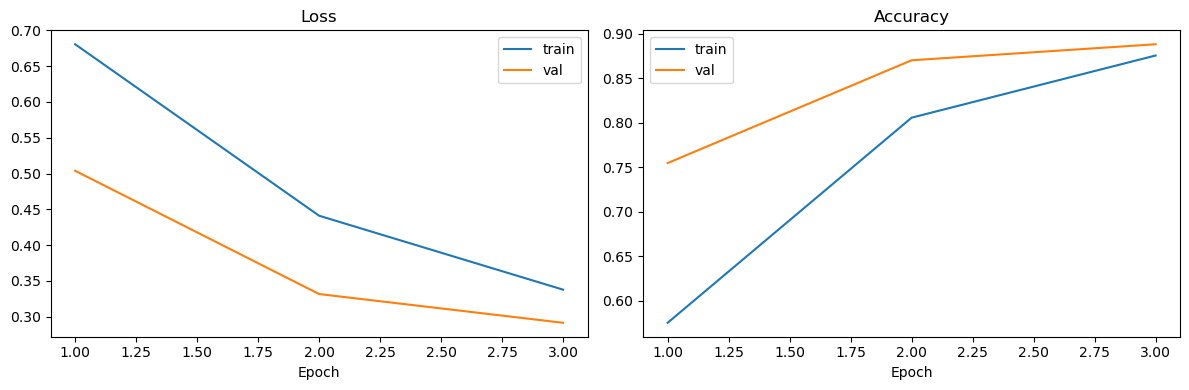

              precision    recall  f1-score   support

not business       0.90      0.95      0.93      1509
    business       0.83      0.69      0.75       491

    accuracy                           0.89      2000
   macro avg       0.87      0.82      0.84      2000
weighted avg       0.88      0.89      0.88      2000



In [6]:
#TODO add a dropout and a ReLU: [CLS] token (128) → Linear → ReLU → Dropout(0.3) → Linear → 2 logits
import torch.nn as nn
import matplotlib.pyplot as plt
from transformers import AutoModel

# Use Apple Silicon GPU (MPS) if available, fall back to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ── Model: bert-tiny backbone + custom head ────────────────────────────────────
class BertTinyClassifier(nn.Module):
    def __init__(self, model_name, hidden_size=128, num_labels=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),  # [CLS] (128) → Linear
            nn.ReLU(),                    # → ReLU
            nn.Dropout(dropout),          # → Dropout(0.3)
            nn.Linear(64, num_labels)     # → 2 logits
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]  # [CLS] token
        return self.classifier(cls)

# ── DataLoaders ────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
train_loader = DataLoader(
    NewsDataset(train_df['text'].values, train_df['business'].values, tokenizer),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    NewsDataset(val_df['text'].values, val_df['business'].values, tokenizer),
    batch_size=BATCH_SIZE
)

# ── Training setup ─────────────────────────────────────────────────────────────
EPOCHS    = 3
model     = BertTinyClassifier(MODEL_NAME).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader),
    num_training_steps=EPOCHS * len(train_loader)
)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # ── train ──────────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_preds, t_labels = 0, [], []
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]"):
        ids, mask, labels = (batch['input_ids'].to(device),
                             batch['attention_mask'].to(device),
                             batch['label'].to(device))
        optimizer.zero_grad()
        loss = criterion(model(ids, mask), labels)
        loss.backward()
        optimizer.step(); scheduler.step()
        t_loss  += loss.item()
        t_preds  += model(ids, mask).argmax(1).cpu().tolist()
        t_labels += labels.cpu().tolist()

    # ── validate ───────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_preds, v_labels = 0, [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            ids, mask, labels = (batch['input_ids'].to(device),
                                 batch['attention_mask'].to(device),
                                 batch['label'].to(device))
            logits = model(ids, mask)
            v_loss  += criterion(logits, labels).item()
            v_preds  += logits.argmax(1).cpu().tolist()
            v_labels += labels.cpu().tolist()

    tl = t_loss / len(train_loader); vl = v_loss / len(val_loader)
    ta = accuracy_score(t_labels, t_preds); va = accuracy_score(v_labels, v_preds)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    print(f"Epoch {epoch+1}: train_loss={tl:.4f} val_loss={vl:.4f} "
          f"train_acc={ta:.4f} val_acc={va:.4f}")

# ── Plot loss and accuracy by epoch ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history['train_loss'], label='train')
ax1.plot(epochs, history['val_loss'],   label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(epochs, history['train_acc'],  label='train')
ax2.plot(epochs, history['val_acc'],    label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

print(classification_report(v_labels, v_preds, target_names=['not business', 'business']))